In [10]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(
    model="llama-3.1-8b-instant"
)

response = llm.invoke("Hello")

print(response.content)

Hello. What would you like to talk about or ask for help with?


In [6]:
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage], add_messages]

In [7]:
def chat_node(state: ChatState):

    #take user query from the state
    messages = state["messages"]

    #send to llm
    response = llm.invoke(messages)

    #response store state
    return {"messages" : response}


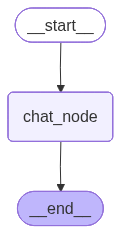

In [12]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile()
chatbot

In [11]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

In [13]:
chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='88499041-8f95-462f-9414-792983265a54'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 41, 'total_tokens': 50, 'completion_time': 0.007187725, 'completion_tokens_details': None, 'prompt_time': 0.001965004, 'prompt_tokens_details': None, 'queue_time': 0.046307066, 'total_time': 0.009152729}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e962c-8017-7522-b243-49b5b2aee5d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 9, 'total_tokens': 50})]}

In [16]:
chatbot.invoke(initial_state)["messages"][-1].content

'The capital of India is New Delhi.'

In [18]:
# simple chatbot with while loop
while True:

    user_message = input("Type here")

    print("User:", user_message)

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        break

    response = chatbot.invoke({"messages": HumanMessage(content=user_message)})

    print("AI: ", response["messages"][-1].content)



User: hi
AI:  How can I help you today?
User: what is capital of delhi?
AI:  Delhi is a union territory in India, and it is not a state with a separate capital. However, I assume you are referring to the fact that Delhi is the capital of India, and within the NCR (National Capital Region) of Delhi, there are several cities that act as administrative and political centers. 

In the context of Delhi, some of the major districts with their administrative headquarters are:

1. New Delhi (the capital district of India)
2. North Delhi
3. North East Delhi
4. East Delhi
5. South Delhi
6. West Delhi
7. Central Delhi
8. Shahdara

However, if you are asking about the capital of the National Capital Territory (NCT) of Delhi, the answer would be New Delhi.
User: okay who is Demis Hassabis?
AI:  Demis Hassabis is a British artificial intelligence (AI) researcher, computer scientist, and entrepreneur. He is best known as one of the co-founders of DeepMind, an AI subsidiary of Alphabet Inc. (the paren

In [19]:
# problems with this chatbot

while True:

    user_message = input("Type here")

    print("User:", user_message)

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        break

    response = chatbot.invoke({"messages": HumanMessage(content=user_message)})

    print("AI: ", response["messages"][-1].content)

User: hi my name is ajay
AI:  Nice to meet you, Ajay. Is there something I can help you with or would you like to chat?
User: can you tell my name?
AI:  I don't have any information about your name. I'm happy to chat with you, but I don't retain any personal data or information about our previous conversations. Each time you interact with me, it's a new conversation. If you'd like to share your name, I'd be happy to learn it!
User: add 15 to 200
AI:  200 + 15 = 215.
User: now add 200 to result
AI:  However, I don't see a result to add 200 to. If you provide a number or a calculation result, I'd be happy to help you add 200 to it.
User: exit


In [25]:
# there is memory issue with this chatbot 
# while we are sending the all the history of chat to it still it is not answering the simple questions
# because with above while loop chatbot the invokation ends with first User and AI message for the second invoke it does not have access to previous messages
# the main issue here is that we are invoking our chat_node again and again from the start

# so we can solve this issue with the langGraph's concept called Persistence
# In Persistance we dont erase the state instead we store the state somewhere in like database, or in RAM memory
# we more use in industry the database memory

In [28]:
# okay now we will apply the persistence concept in this chatbot
# here we will save the chats in the RAM memory not in databases later we can do with database
# so for this we can use 
# from langgraph.checkpoint.memory import MemorySaver

### Adding Persistence Feature

In [29]:
from langgraph.checkpoint.memory import MemorySaver

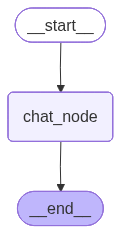

In [30]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [31]:
# simple chatbot with while loop and persistence memory feature
thread_id = "1"

while True:

    user_message = input("Type here")

    print("User:", user_message)

    if user_message.strip().lower() in ["exit", "quit", "bye"]:
        break


    config = {"configurable" : {"thread_id" : thread_id}}

    response = chatbot.invoke({"messages": HumanMessage(content=user_message)}, config=config)

    print("AI: ", response["messages"][-1].content)

User: hello my name is ajay
AI:  Hello Ajay, it's nice to meet you. Is there something I can help you with or would you like to chat?
User: can you tell me what is my name?
AI:  Your name is Ajay.
User: okay now tell me what is 101 + 121
AI:  To calculate the result, I'll add 101 and 121:

101 + 121 = 222

So the result is 222.
User: okay good now add 999 in it
AI:  To add 999 to 222, I'll calculate:

222 + 999 = 1221

So the result is 1221.
User: okay thank you
AI:  It was a pleasure helping you, Ajay. If you need anything else, feel free to ask.
User: bye


In [32]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hello my name is ajay', additional_kwargs={}, response_metadata={}, id='a8e0a12f-abc7-4131-b8bf-c5321c8c4902'), AIMessage(content="Hello Ajay, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.023626031, 'completion_tokens_details': None, 'prompt_time': 0.002738679, 'prompt_tokens_details': None, 'queue_time': 0.158973411, 'total_time': 0.02636471}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e965e-dc2d-73b1-9dcc-01c276ae1214-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68}), HumanMessage(content='can you tell me what is my name?', add

In [33]:
state = chatbot.get_state(config=config)
for msg in state.values["messages"]:
    print(f"\n{msg.__class__.__name__}")
    print(msg.content)


HumanMessage
hello my name is ajay

AIMessage
Hello Ajay, it's nice to meet you. Is there something I can help you with or would you like to chat?

HumanMessage
can you tell me what is my name?

AIMessage
Your name is Ajay.

HumanMessage
okay now tell me what is 101 + 121

AIMessage
To calculate the result, I'll add 101 and 121:

101 + 121 = 222

So the result is 222.

HumanMessage
okay good now add 999 in it

AIMessage
To add 999 to 222, I'll calculate:

222 + 999 = 1221

So the result is 1221.

HumanMessage
okay thank you

AIMessage
It was a pleasure helping you, Ajay. If you need anything else, feel free to ask.
